<a href="https://colab.research.google.com/github/VictorTrasancos/Sydney-Airbnb-Prediction/blob/main/Sydney_Airbnb_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
# Manipulação dos Dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de regressão
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# Métricas de regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

#Árvore de Decisão
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.tree import export_text

#Floresta aleatória
from sklearn.ensemble import RandomForestRegressor

Passo 1: Obtenção dos Dados

In [ ]:
# URL do dataset
GITHUB_URL = (
    "https://raw.githubusercontent.com/Finance-781/FinML/master/"
    "Lecture%202%20-%20End-to-End%20ML%20Project%20/Practice/datasets/"
    "sydney_airbnb.csv"
)

df = pd.read_csv(GITHUB_URL)
print("O tamanho do dataset é:", df.shape)
df.head()


Passo 2: Limpeza dos Dados

In [ ]:
# Tipos de dados
df.info()
df = df.drop_duplicates()

# Removendo colunas
# As colunas abaixo estão sendo excluídas por por possuírem poucos valores não nulos
# e por possuírem pouca relevância pro nosso projeto
df = df.drop(columns=[
    'neighbourhood_group_cleansed', 'square_feet', 'weekly_price',
    'monthly_price', 'extra_people', 'host_about', 'notes',
    'transit', 'interaction', 'access', 'smart_location',
    'thumbnail_url', 'medium_url', 'xl_picture_url',
    'host_thumbnail_url', 'host_picture_url', 'id', 'listing_url',
    'host_url', 'host_id', 'picture_url', 'host_name', 'name',
    'summary', 'space', 'description', 'neighborhood_overview',
    'house_rules', 'country', 'country_code', 'state', 'require_guest_profile_picture',
    'host_neighbourhood', 'host_verifications', 'calendar_updated', 'street', 'zipcode',
    'host_location', 'host_has_profile_pic'
], errors='ignore')


# Tratamento das colunas monetárias
df['price']=df['price'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)
df['cleaning_fee']=df['cleaning_fee'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)
df['security_deposit']=df['security_deposit'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)

df = df.dropna(subset=['price'])
df['cleaning_fee'] = df['cleaning_fee'].fillna(0)
df['security_deposit'] = df['security_deposit'].fillna(0)

# Tratamento das colunas em formato de data
df['host_since']=pd.to_datetime(df['host_since'],errors='coerce')
df['first_review']=pd.to_datetime(df['first_review'],errors='coerce')
df['last_review']=pd.to_datetime(df['last_review'],errors='coerce')

# Tratamento de colunas binárias
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1,'f' : 0, True: 1, False: 0})
df['host_identity_verified'] = df['host_identity_verified'].map({'t': 1,'f' : 0, True: 1, False: 0})
df['instant_bookable'] = df['instant_bookable'].map({'t': 1,'f' : 0, True: 1, False: 0})
df['is_location_exact'] = df['is_location_exact'].map({'t': 1,'f' : 0, True: 1, False: 0})

Parte 3: Estatística descritiva e análise exploratória (EDA)

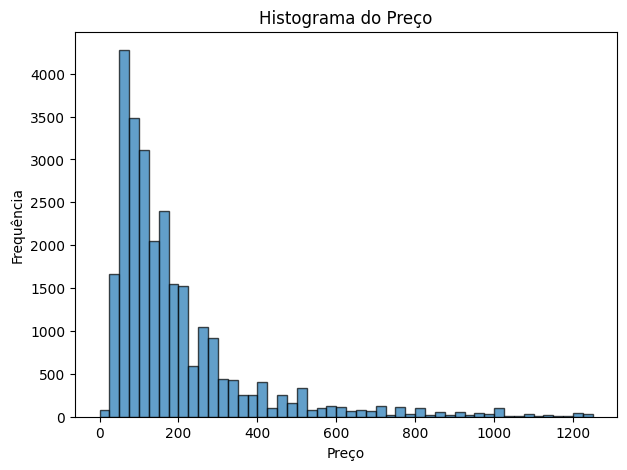

In [83]:
# Verificando se a limpeza feita anteriormente foi eficiente em eliminar possíveis distorções
df.describe()

# Criando um histograma para analisar a variável price
preco_limite = df['price'].quantile(0.99)
df_filtrado = df[df['price'] <= preco_limite]

plt.figure(figsize=(7,5))
plt.hist(df_filtrado['price'],bins=50,density=False,edgecolor='black',alpha=0.7)
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.title('Histograma do Preço')
plt.show()

# Notamos que a maior quantidade de hoteis possui preço na faixa de 0 a 200 dólares

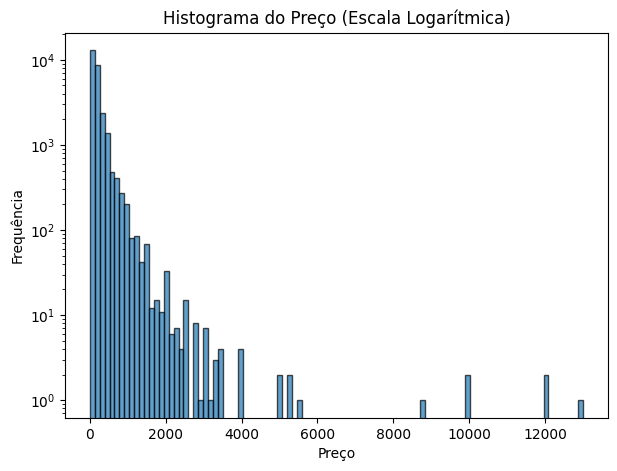

In [84]:
# Analisando o preço através da escala logaritmica

plt.figure(figsize=(7,5))
plt.hist(df['price'], bins=100,edgecolor='black',alpha=0.7)
plt.yscale('log')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.title('Histograma do Preço (Escala Logarítmica)')
plt.show()

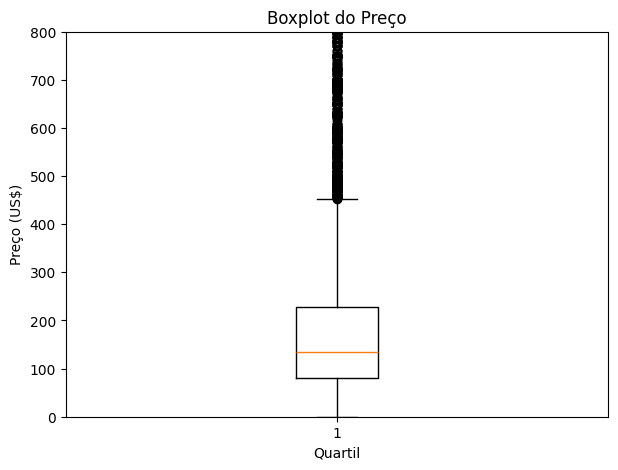

In [85]:
# Visualização do preço através de um boxplot

# Devido a forte presença de outliers, para melhorar a visualização da caixa do boxplot
# optei por limitar o eixo y em 800 US$ ( Em 1500US$ e 1000US$ a visualização continuava prejudicada)
plt.figure(figsize=(7,5))
plt.boxplot(df['price'])
plt.ylabel('Preço (US$)')
plt.xlabel('Quartil')
plt.title('Boxplot do Preço')
plt.ylim(0,800)
plt.show()

(0.0, 700.0)

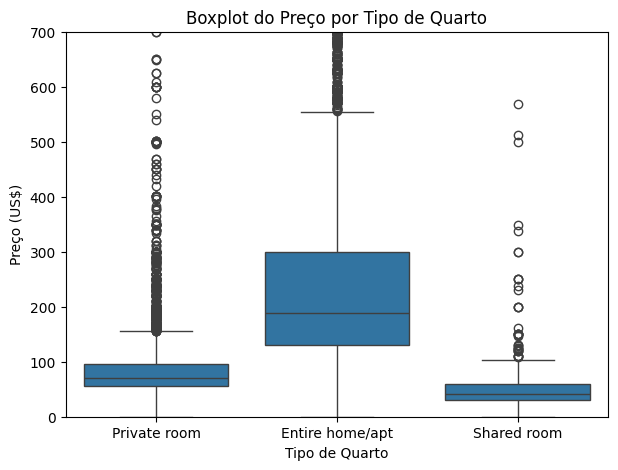

In [86]:
# Analise do preço com base no tipo de quarto

# Novamente precisei limitar o eixo y para facilitar a caixa principal do boxplot
plt.figure(figsize=(7,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.ylabel('Preço (US$)')
plt.xlabel('Tipo de Quarto')
plt.title('Boxplot do Preço por Tipo de Quarto')
plt.ylim(0,700)

# Notamos que a mediana dos apartamentos interiros é praticamente duas vezes maior que
# quartos compartilhados ou quartos privados. Os shared rooms são uma melhor opção financeira
# que os outros dois tipos e apresenta bem menos outliers.

(0.0, 700.0)

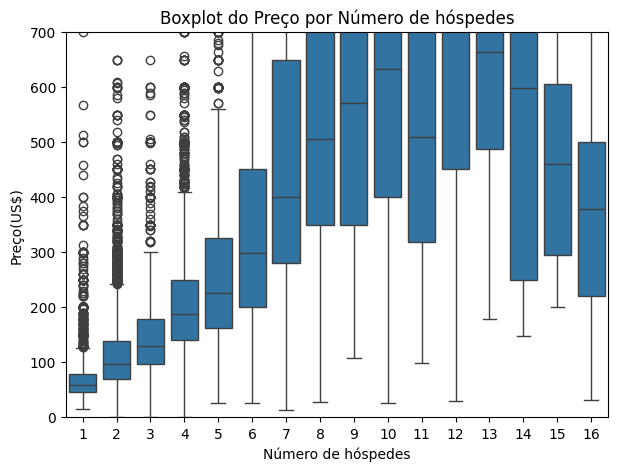

In [87]:
# Analise do preço e do número de hospedes

plt.figure(figsize=(7,5))
sns.boxplot(x='accommodates',y='price',data=df)
plt.ylabel('Preço(US$)')
plt.xlabel('Número de hóspedes')
plt.title('Boxplot do Preço por Número de hóspedes')
plt.ylim(0,700)

# Nota-se que conforme a quantidade de hóspedes cresce sua mediana de preços também cresce

(0.0, 700.0)

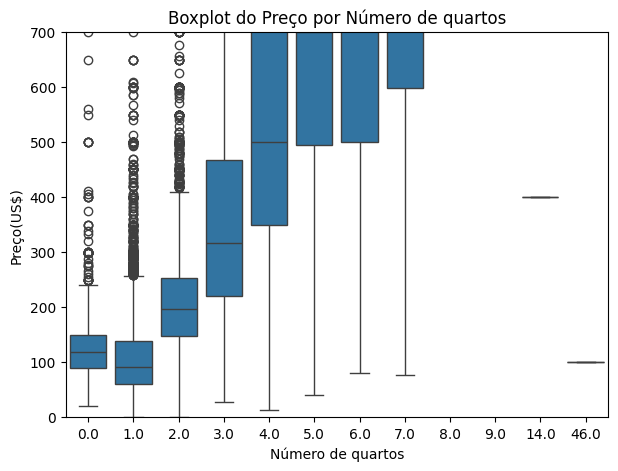

In [88]:
# Analise do preço e do número de quartos

plt.figure(figsize=(7,5))
sns.boxplot(x='bedrooms',y='price',data=df)
plt.ylabel('Preço(US$)')
plt.xlabel('Número de quartos')
plt.title('Boxplot do Preço por Número de quartos')
plt.ylim(0,700)

# Com essa análise encontrei imóveis com muitos quartos alugados a valores baixos
# Filtraremos valores granes de quartos

In [89]:
df = df[df['bedrooms']<10]

#Removendo outliers em anuncios
df = df[(df['price'] >= 20) & (df['price'] <= 1000)].copy()

# Dessa forma os dados estão mais coesos

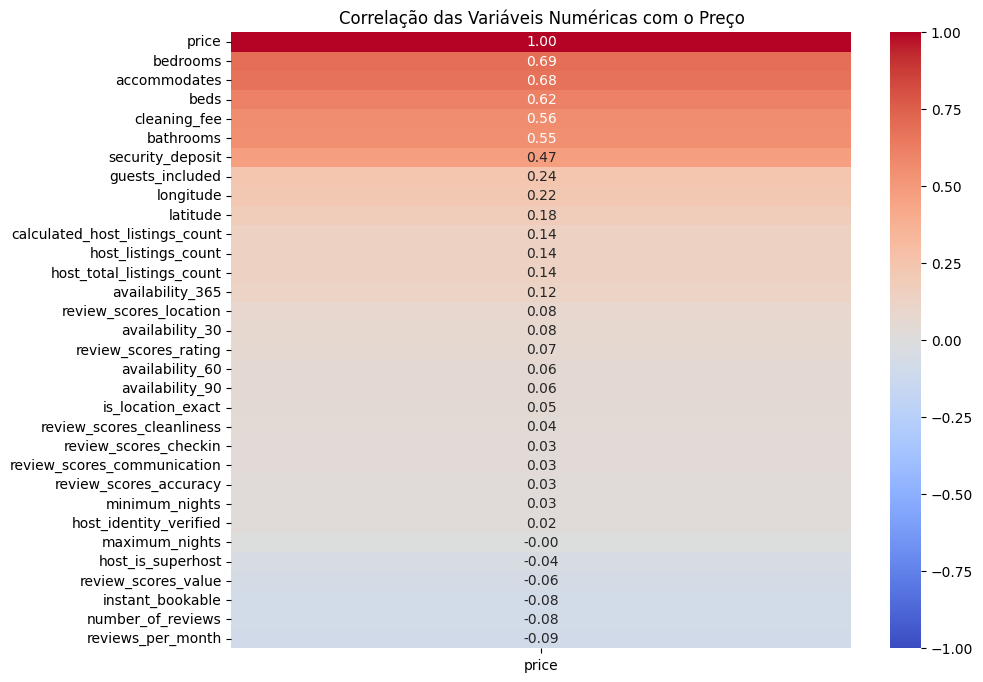

In [90]:
# Heatmap para encontrar as correlações entre as variáveis númericas e o preço

correlacao = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlacao[['price']].sort_values(by = 'price',ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlação das Variáveis Numéricas com o Preço')
plt.show()

Parte 4 - Divisão treino/teste estratificada

In [91]:
# Como ja exclui algumas colunas na parte 2, vou me atentar em melhoras as colunas existentes

data_atual = pd.to_datetime('2026-09-26')
# Mais facil analisar um número(anos) do que uma data
if 'host_since' in df.columns:
  df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
  df['host_years_active'] = (data_atual - df['host_since']).dt.days / 365
  df = df.drop(columns=['host_since'])

if 'amenities' in df.columns:
  # Verificando quantos itens de comodidade existem, pois sua correlação com os preços é alta
  df['amenities_count'] = df['amenities'].astype(str).apply(lambda x: len(x.split(',')))
  df = df.drop(columns=['amenities'])

if 'last_review' in df.columns:
  # Mesmo principio do host_since
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    df['days_since_last_review'] = (data_atual - df['last_review']).dt.days.fillna(999)
    df = df.drop(columns=['first_review', 'last_review'], errors='ignore')

if 'host_response_rate' in df.columns:
    # transformando em um decimal
    df['host_response_rate'] = df['host_response_rate'].str.rstrip('%').astype(float) / 100

In [92]:
# Agrega as latitudes e longitudes para obter a distancia em km do centro de Sydney
lat_centro, lon_centro = -33.8688, 151.2093
lon1, lat1, lon2, lat2 = map(np.radians, [df['longitude'], df['latitude'], lon_centro, lat_centro])
dlon, dlat = lon2 - lon1, lat2 - lat1
a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
df['dist_centro_km'] = 6371 * 2 * np.arcsin(np.sqrt(a))
print("Distância ao centro calculada")

Distância ao centro calculada


In [93]:
# Transformando essas colunas em binárias
if 'require_guest_phone_verification' in df.columns:
    df['require_guest_phone_verification'] = df['require_guest_phone_verification'].map({'t': 1, 'f': 0, True: 1, False: 0})


In [94]:
# Eliminação de colunas redundantes
df = df.drop(columns=[
    'host_since', 'first_review', 'last_review', 'amenities',
    'neighbourhood', 'city', 'market', 'has_availability'
], errors='ignore')

Parte 5: Engenharia de atributos

In [95]:
# Separando o que queremos prever ( df['price']) das outras colunas

# X são as features e y é o que queremos predizer
X = df.drop(columns=['price'])
y = df['price']

# Dividindo o dataset em treino e teste
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=df['room_type'] # Variavel categorica
)

print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")

Formato dos dados de treino (X_train): (21291, 43)
Formato dos dados de teste (X_test): (5323, 43)


In [96]:
# Agrupando as propriedades
top_properties = X_train['property_type'].value_counts().nlargest(5).index
X_train['property_type'] = X_train['property_type'].apply(lambda x: x if x in top_properties else 'Other')
X_test['property_type'] = X_test['property_type'].apply(lambda x: x if x in top_properties else 'Other')

In [97]:
# Preenchimento de valores vazios com a mediana, para evitar muitas distorções
colunas_contagem = ['beds', 'bathrooms', 'bedrooms', 'host_is_superhost', 'security_deposit', 'cleaning_fee']
for col in colunas_contagem:
    if col in X_train.columns:
        mediana_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(mediana_val)
        X_test[col] = X_test[col].fillna(mediana_val)

# Preenchimento com zero
colunas_reviews = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month'
]

for col in colunas_reviews:
  if col in X_train.columns:
    # Imoveis novos podem não ter recebido avaliação e se fossem simplesmente preenchidos com zero
    # o modelo poderia entender que as notas sao ruins
        X_train[col + 'missing'] = X_train[col].isna().astype(int)
        X_test[col + 'missing'] = X_test[col].isna().astype(int)
        X_train[col] = X_train[col].fillna(0)
        X_test[col] = X_test[col].fillna(0)


print('Tratamento de valores')
print(f"Valores nulos restantes no DataFrame: {df.isna().sum().sum()}")

Tratamento de valores
Valores nulos restantes no DataFrame: 85237


In [99]:
#preenchimento de valores ausentes no tipo object
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].fillna('Desconhecido')
    X_test[col] = X_test[col].fillna('Desconhecido')

In [100]:
#preenchimento de valores ausentes no tipo numero
for col in X_train.select_dtypes(include=['int64', 'float64']).columns:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

In [101]:
# Realizando o one-hot enconding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [102]:
# Verificar a quantidade de ausentes
print(f"X_train preparado: {X_train.shape} | Nulos restantes: {X_train.isna().sum().sum()}")
print(f"X_test preparado:  {X_test.shape} | Nulos restantes: {X_test.isna().sum().sum()}")

X_train preparado: (21291, 101) | Nulos restantes: 0
X_test preparado:  (5323, 101) | Nulos restantes: 0


Parte 6: Pipeline de pré-processamento

In [106]:
from sklearn.preprocessing import StandardScaler

# padronização dos dados
scaler = StandardScaler()

# fit deve ser usado apenas no X_train
X_train_scaled = scaler.fit_transform(X_train)
# transform deve ser aplicado em X_train e X_test
X_test_scaled = scaler.transform(X_test)

print('Padronização concluida!')
print(f'Novas dimensões após padronização do X_train_scaled: {X_train_scaled.shape}')

Padronização concluida!
Novas dimensões após padronização do X_train_scaled: (21291, 101)


Parte 7: Modelos supervisionados com ajuste de hiperparâmetros

In [107]:
# Testando primeiro a regressão Linear
print(' Testando Regressão Linear')
lr_model = LinearRegression()
lr_model.fit(X_train_scaled,  np.log1p(y_train))
y_pred_log = lr_model.predict(X_test_scaled)
# Converte novamente para dólares
y_pred_lr = np.expm1(y_pred_log)

print(f'Regressão Linear - R2: {r2_score(y_test,y_pred_lr)}')
print(f'Regressão Linear - MAE {mean_absolute_error(y_test,y_pred_lr)}')
print(f'Regressão Linear - MSE {mean_squared_error(y_test,y_pred_lr)}')

 Testando Regressão Linear
Regressão Linear - R2: 0.6577279995289884
Regressão Linear - MAE 55.16074994202736
Regressão Linear - MSE 9357.475491008678


In [108]:
# Criação da árvore de decisão

# Definindo dicionário de hiperparâmetros
dt_params = {
    'max_depth': [3,5,10,15,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,5]
}

# Criando árvore de decisão para regressão
dt_model = DecisionTreeRegressor(random_state=42)

# GridSearchCV para encontrar a melhor combinação de hiperparâmetros
dt_grid = GridSearchCV(
    estimator = dt_model,
    param_grid = dt_params,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

# 4. Ajustar o modelo aos dados de treino já padronizados
print("Treinando a Árvore de Decisão")
dt_grid.fit(X_train_scaled, y_train)

# Obtendo a melhor combinação de hiperparâmetros
melhor_dt = dt_grid.best_estimator_
print(f"Melhor combinação de hiperparâmetros: {melhor_dt}")

# Fazer predição baseado no melhor estimador
y_pred_dt = melhor_dt.predict(X_test_scaled)

# Calculando as métricas
print("Métricas da árvore de decisão")
print(f"R2 Score : {r2_score(y_test, y_pred_dt):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_dt):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred_dt):.4f}")

Treinando a Árvore de Decisão
Melhor combinação de hiperparâmetros: DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42)
Métricas da árvore de decisão
R2 Score : 0.6163
MAE      : 62.4991
MSE      : 10489.6700


In [109]:
# Floresta Aleatoria

# Definindo dicionário de hiperparâmetros
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [5],
    'min_samples_leaf': [2]
}

# Criando floresta aleatoria para regressão
rf_model = RandomForestRegressor(random_state=42)

# GridSearchCV para encontrar a melhor combinação de hiperparâmetros
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print('Treinando floresta aleatoria')
rf_grid.fit(X_train_scaled, y_train)

# Obtendo a melhor combinação de hiperparâmetros
melhor_rf = rf_grid.best_estimator_
print(f"Melhor combinação de hiperparâmetros: {melhor_rf}")

# Fazer predição baseado no melhor estimador
y_pred_rf = melhor_rf.predict(X_test_scaled)

#Métricas da floresta
print('Métricas da floresta aleatoria')
print(f"R2 Score : {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred_rf):.4f}")


Treinando floresta aleatoria
Melhor combinação de hiperparâmetros: RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, random_state=42)
Métricas da floresta aleatoria
R2 Score : 0.7051
MAE      : 54.1261
MSE      : 8062.8150


Passo 8: Regularização

In [110]:
from sklearn.linear_model import Ridge

# Mantendo o log
y_train_log = np.log1p(y_train)

print('Ajustando Ridge - L2')
ridge_param = {'alpha': [0.1,1.0,10.0,50.0,100.0]}
ridge_grid = GridSearchCV(Ridge(), ridge_param, cv=5,scoring='r2',n_jobs=-1)
ridge_grid.fit(X_train_scaled,y_train_log)

# Melhor estimador
melhor_ridge = ridge_grid.best_estimator_
y_pred_ridge_log = melhor_ridge.predict(X_test_scaled)
y_pred_ridge = np.expm1(y_pred_ridge_log)

print(f"Melhor Alpha (Ridge): {ridge_grid.best_params_['alpha']}")
print(f"Ridge - R2 : {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Ridge - MAE: US$ {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"Ridge - MSE: {mean_squared_error(y_test, y_pred_ridge):.4f}")


Ajustando Ridge - L2
Melhor Alpha (Ridge): 10.0
Ridge - R2 : 0.6577
Ridge - MAE: US$ 55.1579
Ridge - MSE: 9357.4274


In [111]:
from sklearn.linear_model import Lasso

print('Ajustando Lasso - L1')
lasso_param = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0]}
lasso_grid = GridSearchCV(Lasso(), lasso_param, cv=5, scoring='r2',n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train_log)

# Melhor estimador
melhor_lasso = lasso_grid.best_estimator_
y_pred_lasso_log = melhor_lasso.predict(X_test_scaled)
y_pred_lasso = np.expm1(y_pred_lasso_log)

print(f"Melhor Alpha (Lasso): {lasso_grid.best_params_['alpha']}")
print(f"Lasso - R2 : {r2_score(y_test, y_pred_lasso):.4f}")
print(f"Lasso - MAE: US$ {mean_absolute_error(y_test, y_pred_lasso):.4f}")
print(f"Lasso - MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")

Ajustando Lasso - L1
Melhor Alpha (Lasso): 0.01
Lasso - R2 : 0.6395
Lasso - MAE: US$ 56.6400
Lasso - MSE: 9854.8531


In [112]:
from sklearn.linear_model import ElasticNet

print('Ajustando Elastic Net')
elasticnet_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.4, 0.6, 0.8]}
elasticnet_grid = GridSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),
    param_grid=elasticnet_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
elasticnet_grid.fit(X_train_scaled,y_train_log)

# melhor estimador
melhor_elastic = elasticnet_grid.best_estimator_
y_pred_elastic_log = melhor_elastic.predict(X_test_scaled)
y_pred_elastic = np.expm1(y_pred_elastic_log)

print(f'Melhores hiperparametros: {elasticnet_grid.best_params_}')
print(f"Elastic Net - R2 Score : {r2_score(y_test, y_pred_elastic):.4f}")
print(f"Elastic Net - MAE      : {mean_absolute_error(y_test, y_pred_elastic):.4f}")
print(f"Elastic Net - MSE      : {mean_squared_error(y_test, y_pred_elastic):.4f}")

Ajustando Elastic Net
Melhores hiperparametros: {'alpha': 0.0001, 'l1_ratio': 0.2}
Elastic Net - R2 Score : 0.6577
Elastic Net - MAE      : 55.1594
Elastic Net - MSE      : 9357.7868


Parte 9: Validação Cruzada

In [113]:
from sklearn.model_selection import cross_val_score
modelos_para_comparar = {
    "Regressão Linear": LinearRegression(),
    "Ridge": Ridge(alpha=10.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "Elastic Net": ElasticNet(alpha=0.001, l1_ratio=0.2, random_state=42),
    "Árvore de Decisão": melhor_dt,
    "Floresta Aleatoria": melhor_rf
}

print('Validação Cruzada')
resultados = {}

for nome, modelo in modelos_para_comparar.items():
    scores = cross_val_score(modelo, X_train_scaled, np.log1p(y_train), cv=5, scoring='r2', n_jobs=-1)
    resultados[nome] = scores.mean()
    print(f"{nome:20} -> R2 Médio: {scores.mean():.4f})")

melhor_modelo = max(resultados, key=resultados.get)
print(f"O melhor modelo foi {melhor_modelo}")

Validação Cruzada
Regressão Linear     -> R2 Médio: -32101.4019)
Ridge                -> R2 Médio: 0.7177)
Lasso                -> R2 Médio: 0.7163)
Elastic Net          -> R2 Médio: 0.7175)
Árvore de Decisão    -> R2 Médio: 0.6775)
Floresta Aleatoria   -> R2 Médio: 0.7390)
O melhor modelo foi Floresta Aleatoria


Parte 10: Avaliação no conjunto de teste.

In [114]:
# Tomaremos as medidas da Floresta Aleatoria

modelo_final = melhor_rf

print('Avaliação no conjunto teste')
# Limpo o teste para evitar valores infinitos
X_test_limpo = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
y_pred_final = modelo_final.predict(X_test_limpo)

# Calculando as metricas a partir da Floresta
r2_final = r2_score(y_test, y_pred_final)
mae_final = mean_absolute_error(y_test, y_pred_final)
mse_final = mean_squared_error(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)

print(f"R2 Score: {r2_final:.4f}")
print(f"MAE: US$ {mae_final:.4f}")
print(f"MSE: {mse_final:.4f}")
print(f"RMSE: {rmse_final:.4f}")

Avaliação no conjunto teste
R2 Score: 0.7051
MAE: US$ 54.1261
MSE: 8062.8150
RMSE: 89.7932


Passo 11: Importância das Variáveis

10 variaveis mais importantes
                  Variável  Importância
10                bedrooms     0.470440
12        security_deposit     0.057801
91  room_type_Private room     0.056466
6                longitude     0.052739
8             accommodates     0.041910
9                bathrooms     0.033508
13            cleaning_fee     0.032054
36          dist_centro_km     0.027006
5                 latitude     0.025339
33       host_years_active     0.020786


/tmp/ipykernel_2470/3879041880.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


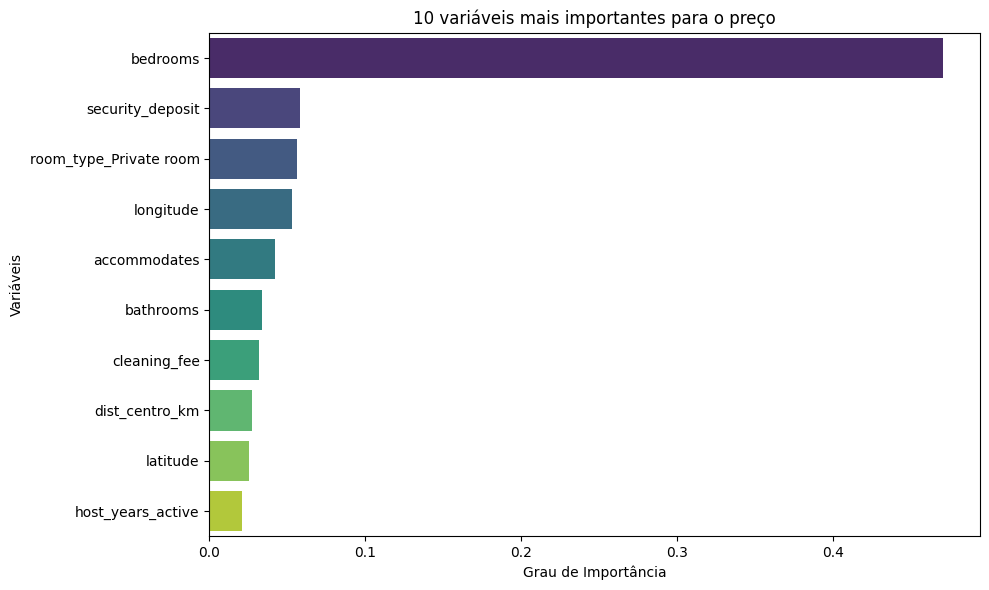

In [115]:
importancia_features = melhor_rf.feature_importances_
df_importancia = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': importancia_features
}).sort_values(by='Importância', ascending=False)

print('10 variaveis mais importantes')
print(df_importancia.head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importância',
    y='Variável',
    data=df_importancia.head(10),
    palette='viridis'
)
plt.title('10 variáveis mais importantes para o preço')
plt.xlabel('Grau de Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

Parte 12: Aplicação prática

In [120]:
novo_imovel = pd.DataFrame([{
    "city": "Bondi Beach",
    "longitude": 151.274506,
    "latitude": -33.889087,
    "review_scores_rating": 95,
    "number_of_reviews": 53,
    "minimum_nights": 4,
    "security_deposit": 1500,
    "cleaning_fee": 370,
    "accommodates": 10,
    "bathrooms": 3,
    "bedrooms": 5,
    "beds": 7,
    "property_type": "House",
    "room_type": "Entire home/apt",
    "availability_365": 255,
    "host_identity_verified": 1,
    "host_is_superhost": 1,
    "cancellation_policy": "strict_14_with_grace_period",
    "host_since": pd.Timestamp("2010-08-01"),
}])

# Filtragem das colunas
data_atual = pd.to_datetime('2026-09-26')
novo_imovel['host_years_active'] = (data_atual - novo_imovel['host_since']).dt.days / 365
novo_imovel = novo_imovel.drop(columns=['host_since'])

# itens de comodidade
if 'amenities' in novo_imovel.columns:
    novo_imovel['amenities_count'] = novo_imovel['amenities'].apply(lambda x: len(x.split(',')))
    novo_imovel = novo_imovel.drop(columns=['amenities'])
else:
    novo_imovel['amenities_count'] = X_train['amenities_count'].median()

# Distancia ate o centro
lat_centro, lon_centro = -33.8688, 151.2093
lon1, lat1, lon2, lat2 = map(np.radians, [novo_imovel['longitude'], novo_imovel['latitude'], lon_centro, lat_centro])
dlon, dlat = lon2 - lon1, lat2 - lat1
a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
novo_imovel['dist_centro_km'] = 6371 * 2 * np.arcsin(np.sqrt(a))

# Tipo de propriedade
novo_imovel['property_type'] = novo_imovel['property_type'].apply(lambda x: x if x in top_properties else 'Other')

novo_imovel = novo_imovel.drop(columns=['city', 'cancellation_policy'], errors='ignore')

novo_imovel = pd.get_dummies(novo_imovel, drop_first=True)
novo_imovel = novo_imovel.reindex(columns=X_train.columns, fill_value=0)
novo_imovel_scaled = scaler.transform(novo_imovel)

preco_estimado = melhor_rf.predict(novo_imovel_scaled)[0]

print('Preço atual cobrado pelo anfitrião de Bond Beach: U$500.00')
print(f'Preço justo avaliado pela Floresta Aleatoria: {preco_estimado:.2f}')

Preço atual cobrado pelo anfitrião de Bond Beach: U$500.00
Preço justo avaliado pela Floresta Aleatoria: 725.49
